In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Libraries imported successfully!")

# Load the cleaned dataset provided by Member 01
df = pd.read_csv('cleaned_heart_data.csv')

X = df.drop('target', axis=1)
y = df['target']

# All members must use the same random_state=42
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data loaded and split for Random Forest. (No scaling required)")

Libraries imported successfully!
Data loaded and split for Random Forest. (No scaling required)


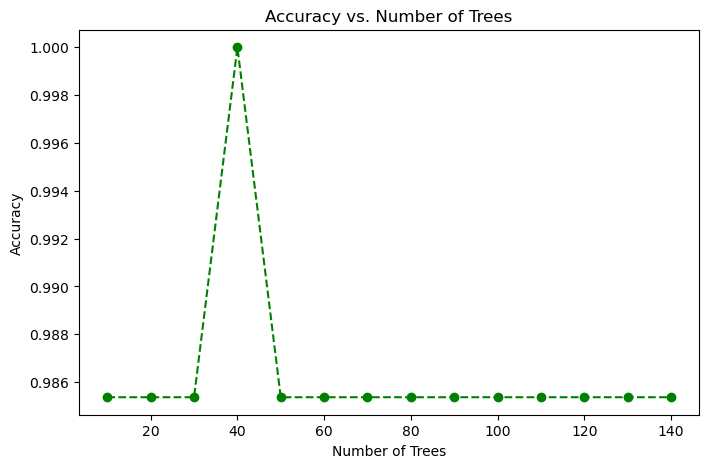

In [3]:
# Hyperparameter Tuning (Finding optimal n_estimators)
scores = []
estimators_range = range(10, 150, 10)

for n in estimators_range:
    rf_temp = RandomForestClassifier(n_estimators=n, random_state=42)
    rf_temp.fit(X_train, y_train)
    scores.append(accuracy_score(y_test, rf_temp.predict(X_test)))

plt.figure(figsize=(8,5))
plt.plot(estimators_range, scores, marker='o', linestyle='dashed', color='green')
plt.title('Accuracy vs. Number of Trees')
plt.xlabel('Number of Trees')
plt.ylabel('Accuracy')
plt.show()

--- Random Forest Evaluation Results ---
Accuracy: 0.9854

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



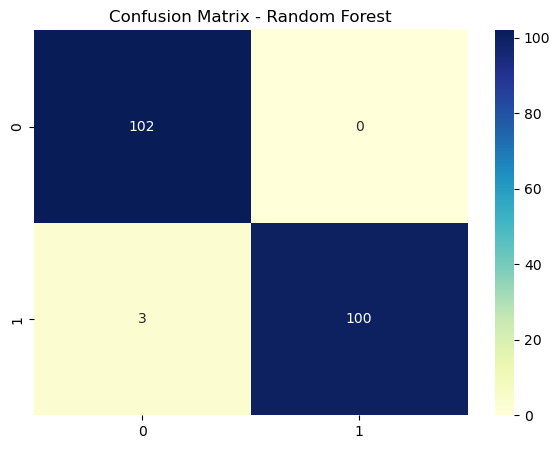

In [4]:
# Train Final Model with 100 trees
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("--- Random Forest Evaluation Results ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

# Confusion Matrix
plt.figure(figsize=(7,5))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='YlGnBu')
plt.title('Confusion Matrix - Random Forest')
plt.show()

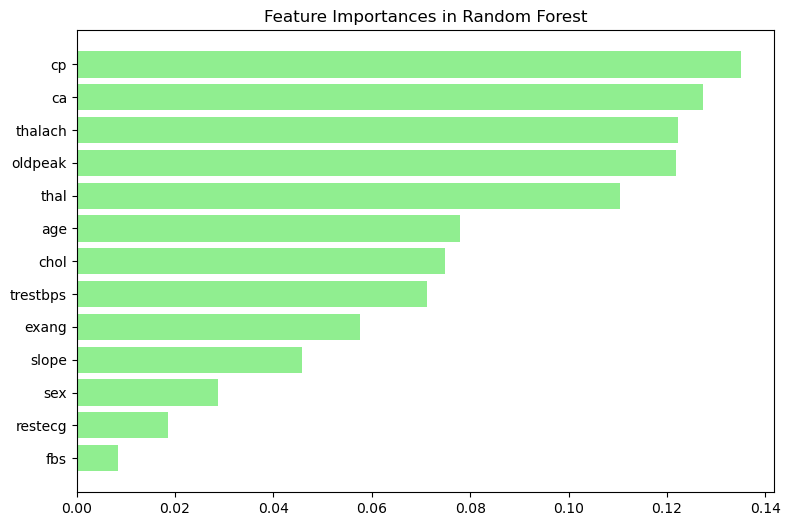

In [5]:
# Feature Importance Analysis 
importances = rf_model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(9,6))
plt.barh(range(len(indices)), importances[indices], color='lightgreen')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.title('Feature Importances in Random Forest')
plt.show()

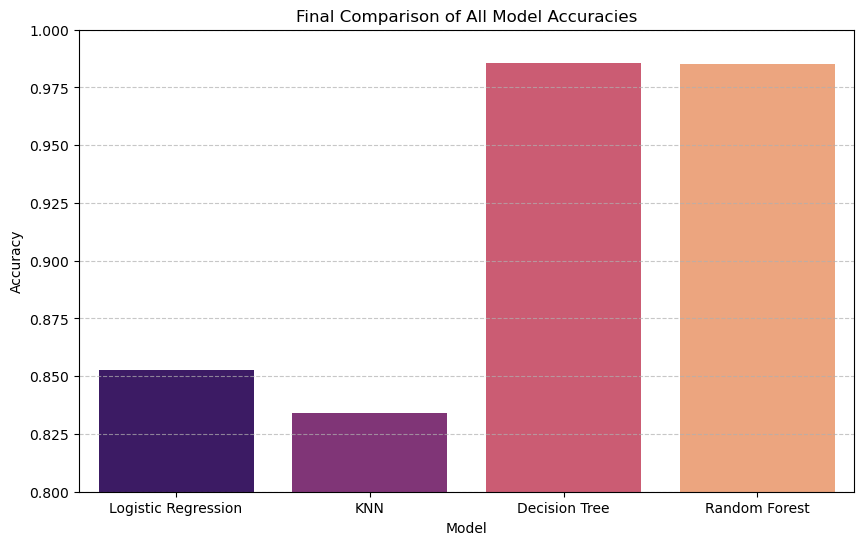

                 Model  Accuracy
0  Logistic Regression  0.852500
1                  KNN  0.834100
2        Decision Tree  0.985400
3        Random Forest  0.985366


In [7]:
# Final Model Comparison (Fixed with correct KNN Accuracy)
results = {
    'Model': ['Logistic Regression', 'KNN', 'Decision Tree', 'Random Forest'],
    'Accuracy': [0.8525, 0.8341, 0.9854, accuracy_score(y_test, y_pred_rf)] 
}

comparison_df = pd.DataFrame(results)

plt.figure(figsize=(10,6))
# Updated code to fix the Seaborn FutureWarning
sns.barplot(x='Model', y='Accuracy', data=comparison_df, hue='Model', palette='magma', legend=False)
plt.ylim(0.8, 1.0) 
plt.title('Final Comparison of All Model Accuracies')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(comparison_df)